# 感知机：从零手撕（1958 Rosenblatt Perceptron）

配套阅读：[docs/01-perceptron-1958.md](../docs/01-perceptron-1958.md)

本 notebook 只用 `numpy`，从零实现感知机学习算法，验证它能学会 AND 门，然后亲眼看它在 XOR 上失败。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']

# 固定随机种子，保证每次运行结果一致
np.random.seed(42)

## 第一步：实现感知机

感知机的核心就两件事：
1. **预测**：$\hat{y} = 1$ 如果 $w_1 x_1 + w_2 x_2 + b > 0$，否则 $\hat{y} = 0$
2. **更新**：如果预测错了，调整权重：$w_i \leftarrow w_i + \eta (y - \hat{y}) x_i$

In [2]:
class Perceptron:
    """
    Rosenblatt 感知机（1958）
    
    参数：
        learning_rate: 学习率 η，每次调整权重的步长
        max_epochs:    最多训练几轮（防止线性不可分时死循环）
    """
    def __init__(self, learning_rate=0.1, max_epochs=100):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.weights = None  # 权重向量
        self.bias = None     # 偏置项
        self.errors_per_epoch = []  # 记录每轮的错误数量，用于可视化

    def predict(self, X):
        """对输入 X（形状 [n_samples, n_features]）做预测。"""
        z = np.dot(X, self.weights) + self.bias  # 加权求和
        return (z > 0).astype(int)               # 阶跃函数

    def fit(self, X, y):
        """
        训练感知机。
        X: 形状 [n_samples, n_features] 的输入
        y: 形状 [n_samples] 的标签（0 或 1）
        """
        n_samples, n_features = X.shape
        
        # 初始化权重为全零（或小随机数也可以）
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for epoch in range(self.max_epochs):
            errors = 0
            
            for i in range(n_samples):
                xi = X[i]          # 当前样本
                yi = y[i]          # 真实标签
                y_hat = self.predict(xi.reshape(1, -1))[0]  # 预测
                
                # 感知机学习规则
                delta = self.lr * (yi - y_hat)  # 误差 × 学习率
                self.weights += delta * xi       # 更新权重
                self.bias += delta               # 更新偏置
                
                if yi != y_hat:
                    errors += 1
            
            self.errors_per_epoch.append(errors)
            
            # 如果这一轮没有错误，提前停止
            if errors == 0:
                print(f"  第 {epoch+1} 轮：0 个错误 → 收敛！")
                break
            else:
                print(f"  第 {epoch+1} 轮：{errors} 个错误")
        else:
            print(f"  达到最大轮数 {self.max_epochs}，未收敛（数据可能线性不可分）")
        
        return self

## 第二步：用 AND 门测试

AND 门是最简单的逻辑门：只有两个输入都是 1 时输出才是 1。

| $x_1$ | $x_2$ | AND |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 0   |
| 1     | 0     | 0   |
| 1     | 1     | 1   |

这是线性可分的（负样本在左下角，正样本在右上角，一条直线可以分开）。

In [3]:
# AND 门训练数据
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_and = np.array([0, 0, 0, 1])  # AND 的真值表

print("=== 训练感知机学习 AND 门 ===")
p_and = Perceptron(learning_rate=0.1, max_epochs=20)
p_and.fit(X_and, y_and)

print("\n训练后的权重：", p_and.weights)
print("训练后的偏置：", p_and.bias)
print("\n预测结果：")
for xi, yi in zip(X_and, y_and):
    pred = p_and.predict(xi.reshape(1, -1))[0]
    status = "✓" if pred == yi else "✗"
    print(f"  AND({xi[0]}, {xi[1]}) = {pred}  (真实: {yi}) {status}")

=== 训练感知机学习 AND 门 ===
  第 1 轮：1 个错误
  第 2 轮：3 个错误
  第 3 轮：3 个错误
  第 4 轮：2 个错误
  第 5 轮：1 个错误
  第 6 轮：0 个错误 → 收敛！

训练后的权重： [0.2 0.1]
训练后的偏置： -0.2

预测结果：
  AND(0, 0) = 0  (真实: 0) ✓
  AND(0, 1) = 0  (真实: 0) ✓
  AND(1, 0) = 0  (真实: 0) ✓
  AND(1, 1) = 1  (真实: 1) ✓


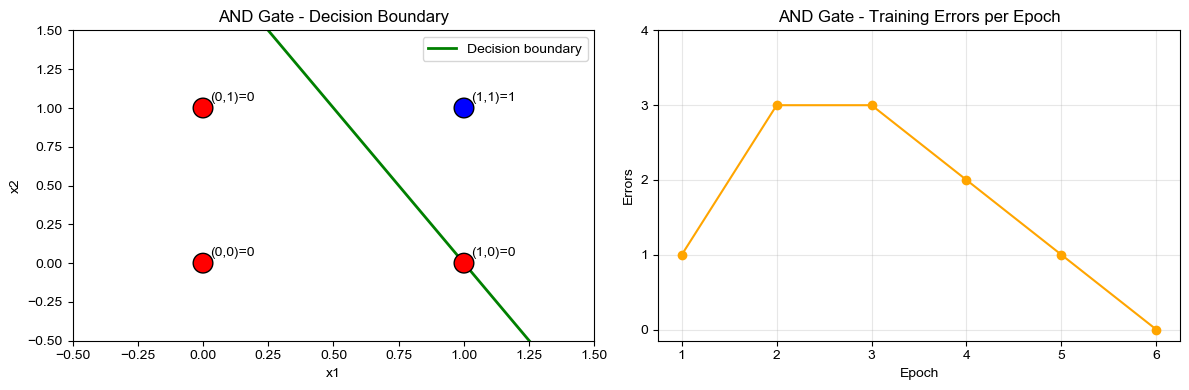

In [4]:
def plot_decision_boundary(model, X, y, title):
    """画出感知机的决策边界（那条分隔线）。"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 左图：散点 + 决策边界
    ax = axes[0]
    colors = ['red' if yi == 0 else 'blue' for yi in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, zorder=5, edgecolors='black')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(f'{title} - Decision Boundary')
    
    # 画决策边界：w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
    w1, w2 = model.weights
    b = model.bias
    if abs(w2) > 1e-10:  # 避免除以零
        x1_range = np.linspace(-0.5, 1.5, 100)
        x2_boundary = -(w1 * x1_range + b) / w2
        ax.plot(x1_range, x2_boundary, 'g-', linewidth=2, label='Decision boundary')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No valid boundary', transform=ax.transAxes, ha='center')
    
    # 标注点
    for xi, yi in zip(X, y):
        ax.annotate(f'({xi[0]},{xi[1]})={yi}', xi, textcoords='offset points', xytext=(5, 5))
    
    # 右图：每轮错误数
    ax2 = axes[1]
    ax2.plot(range(1, len(model.errors_per_epoch)+1), model.errors_per_epoch, 'o-', color='orange')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Errors')
    ax2.set_title(f'{title} - Training Errors per Epoch')
    ax2.set_yticks(range(0, max(model.errors_per_epoch)+2))
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../docs/img_{title.lower().replace(" ", "_")}.png', dpi=80, bbox_inches='tight')
    plt.show()

import os
os.makedirs('../docs', exist_ok=True)
plot_decision_boundary(p_and, X_and, y_and, 'AND Gate')

## 第三步：用 OR 门验证

OR 门：至少一个输入为 1 时输出为 1。也是线性可分的。

In [5]:
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or  = np.array([0, 1, 1, 1])  # OR

print("=== 训练感知机学习 OR 门 ===")
p_or = Perceptron(learning_rate=0.1, max_epochs=20)
p_or.fit(X_or, y_or)

preds = p_or.predict(X_or)
correct = np.sum(preds == y_or)
print(f"\n准确率: {correct}/{len(y_or)} = {correct/len(y_or)*100:.0f}%")

=== 训练感知机学习 OR 门 ===
  第 1 轮：1 个错误
  第 2 轮：2 个错误
  第 3 轮：1 个错误
  第 4 轮：0 个错误 → 收敛！

准确率: 4/4 = 100%


## 第四步：XOR 的失败

XOR（异或）：两个输入**不同**时输出 1，**相同**时输出 0。

| $x_1$ | $x_2$ | XOR |
|-------|-------|-----|
| 0     | 0     | 0   |
| 0     | 1     | 1   |
| 1     | 0     | 1   |
| 1     | 1     | 0   |

正样本 (0,1) 和 (1,0) 在对角线上，负样本 (0,0) 和 (1,1) 在另一条对角线——**找不到一条直线把它们分开**。

In [6]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor  = np.array([0, 1, 1, 0])  # XOR

print("=== 尝试训练感知机学习 XOR 门（预期失败）===")
p_xor = Perceptron(learning_rate=0.1, max_epochs=50)
p_xor.fit(X_xor, y_xor)

print("\nXOR 预测结果：")
for xi, yi in zip(X_xor, y_xor):
    pred = p_xor.predict(xi.reshape(1, -1))[0]
    status = "✓" if pred == yi else "✗"
    print(f"  XOR({xi[0]}, {xi[1]}) = {pred}  (真实: {yi}) {status}")

print("\n→ 感知机无法收敛，证明 XOR 是线性不可分问题")

=== 尝试训练感知机学习 XOR 门（预期失败）===
  第 1 轮：2 个错误
  第 2 轮：3 个错误
  第 3 轮：4 个错误
  第 4 轮：4 个错误
  第 5 轮：4 个错误
  第 6 轮：4 个错误
  第 7 轮：4 个错误
  第 8 轮：4 个错误
  第 9 轮：4 个错误
  第 10 轮：4 个错误
  第 11 轮：4 个错误
  第 12 轮：4 个错误
  第 13 轮：4 个错误
  第 14 轮：4 个错误
  第 15 轮：4 个错误
  第 16 轮：4 个错误
  第 17 轮：4 个错误
  第 18 轮：4 个错误
  第 19 轮：4 个错误
  第 20 轮：4 个错误
  第 21 轮：4 个错误
  第 22 轮：4 个错误
  第 23 轮：4 个错误
  第 24 轮：4 个错误
  第 25 轮：4 个错误
  第 26 轮：4 个错误
  第 27 轮：4 个错误
  第 28 轮：4 个错误
  第 29 轮：4 个错误
  第 30 轮：4 个错误
  第 31 轮：4 个错误
  第 32 轮：4 个错误
  第 33 轮：4 个错误
  第 34 轮：4 个错误
  第 35 轮：4 个错误
  第 36 轮：4 个错误
  第 37 轮：4 个错误
  第 38 轮：4 个错误
  第 39 轮：4 个错误
  第 40 轮：4 个错误
  第 41 轮：4 个错误
  第 42 轮：4 个错误
  第 43 轮：4 个错误
  第 44 轮：4 个错误
  第 45 轮：4 个错误
  第 46 轮：4 个错误
  第 47 轮：4 个错误
  第 48 轮：4 个错误
  第 49 轮：4 个错误
  第 50 轮：4 个错误
  达到最大轮数 50，未收敛（数据可能线性不可分）

XOR 预测结果：
  XOR(0, 0) = 1  (真实: 0) ✗
  XOR(0, 1) = 1  (真实: 1) ✓
  XOR(1, 0) = 0  (真实: 1) ✗
  XOR(1, 1) = 0  (真实: 0) ✓

→ 感知机无法收敛，证明 XOR 是线性不可分问题


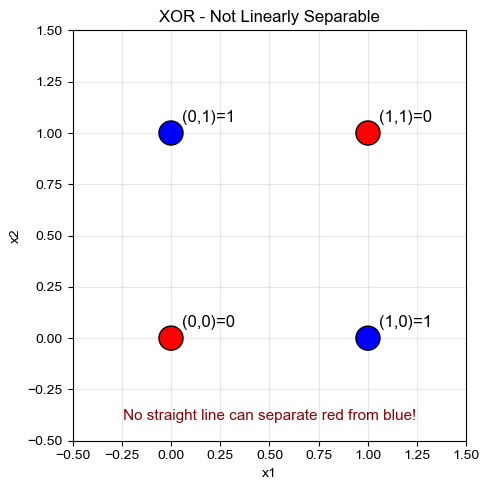

图像已保存


In [7]:
# 可视化 XOR 的"无法分割"
fig, ax = plt.subplots(figsize=(5, 5))
colors = ['red' if yi == 0 else 'blue' for yi in y_xor]
labels = ['Negative (y=0)' if yi == 0 else 'Positive (y=1)' for yi in y_xor]
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=300, zorder=5, edgecolors='black')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('XOR - Not Linearly Separable')
for xi, yi in zip(X_xor, y_xor):
    ax.annotate(f'({xi[0]},{xi[1]})={yi}', xi, textcoords='offset points', xytext=(8, 8), fontsize=12)
ax.text(0.5, -0.4, 'No straight line can separate red from blue!',
        ha='center', fontsize=11, color='darkred', style='italic')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/img_xor.png', dpi=80, bbox_inches='tight')
plt.show()
print("图像已保存")

## 总结

本 notebook 展示了：

1. ✅ **感知机能学习线性可分问题**（AND 门、OR 门）——训练几轮就收敛
2. ❌ **感知机无法解决非线性问题**（XOR）——无论训练多少轮，始终有错误

这个局限在 1969 年由 Minsky & Papert 用数学证明。解决方案是**多层网络 + 反向传播**，要等到 1986 年才出现。

**下一节点**：[02 · 反向传播：让多层网络能学习（1986）]（待更新）